# Smart City Energy Pipeline 


## Roadmap

1. Data loading (controlled slice for rapid iteration)
2. Data preprocessing (missing values, type fixes)
3. Feature engineering (calendar encodings, renewable ratios, lag/rolling load history)
4. Outlier detection & correction (IQR capping)
5. Univariate, bivariate, multivariate analysis
6. Modeling with Linear Regression & Random Forest
7. Evaluation charts and key takeaways

In [31]:
# Core data and modeling libraries only
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

## 1. Data Loading

We read a controlled slice with just the fields needed for storytelling and parse timestamps for time-aware features.

In [32]:
DATA_PATH = "../data/smart_city_energy_dataset.csv"
SELECTED_COLUMNS = [
    "Timestamp",
    "Electricity Load",
    "Temperature (°C)",
    "Humidity (%)",
    "Solar PV Output (kW)",
    "Wind Power Output (kW)",
]

raw_df = pd.read_csv(
    DATA_PATH,
    usecols=SELECTED_COLUMNS,
    parse_dates=["Timestamp"],
    nrows=150_000,
)
raw_df = raw_df.sort_values("Timestamp").reset_index(drop=True)
print(f"Loaded shape: {raw_df.shape}")
raw_df.head()

Loaded shape: (72960, 6)


,Timestamp,Solar PV Output (kW),Wind Power Output (kW),Temperature (°C),Humidity (%),Electricity Load
0,2021-01-01 00:00:00,26.711357,89.955936,27.751690,26.752728,209.578166
1,2021-01-01 00:30:00,9.158357,31.444883,36.734599,5.300440,711.329436
2,2021-01-01 01:00:00,28.972804,16.262761,9.081235,39.869765,434.571941
3,2021-01-01 01:30:00,50.747398,165.385627,8.856865,24.710236,119.913430
4,2021-01-01 02:00:00,12.410062,308.199156,13.782261,12.330477,747.746618


## 2. Data Preprocessing

Handle missing values, enforce numeric types, and keep the working dataframe (`df`) ready for feature work.

In [33]:
df = raw_df.copy()

# Basic NA handling: forward/backward fill keeps sequences intact for lag creation.
df = df.ffill().bfill()

# Quick duplicate sweep keeps only the earliest reading per timestamp.
duplicate_rows = df.duplicated(subset=["Timestamp"]).sum()
df = df.drop_duplicates(subset=["Timestamp"])

print(f"Duplicates removed: {duplicate_rows}")
df.describe().T[["mean", "std", "min", "max"]].round(2)

Duplicates removed: 0


,mean,std,min,max
Timestamp,2023-01-30 23:45:00,NaN,2021-01-01 00:00:00,2025-02-28 23:30:00
Solar PV Output (kW),49.968334,50.404328,0.000215,589.844639
Wind Power Output (kW),80.127652,80.141348,0.000607,988.833205
Temperature (°C),20.004404,10.025481,-22.986633,62.065148
Humidity (%),28.553542,15.967431,0.079897,90.533259
Electricity Load,451.125946,261.919067,-36.072597,2626.808971


## 3. Feature Engineering

Blend classic calendar buckets with sine/cosine encodings, renewable penetration ratios, and strictly lagged/rolling load history so models get rich context without data leakage.

In [34]:
df = df.sort_values("Timestamp").reset_index(drop=True)

df["hour"] = df["Timestamp"].dt.hour
df["dayofweek"] = df["Timestamp"].dt.dayofweek
df["weekofyear"] = df["Timestamp"].dt.isocalendar().week.astype(int)
df["month"] = df["Timestamp"].dt.month
df["dayofyear"] = df["Timestamp"].dt.dayofyear
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)
df["sin_dayofyear"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["cos_dayofyear"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

df["temp_humidity_interaction"] = df["Temperature (°C)"] * df["Humidity (%)"]
renewable_total = df["Solar PV Output (kW)"] + df["Wind Power Output (kW)"]
df["renewable_penetration"] = (
    (renewable_total / df["Electricity Load"].replace(0, np.nan)).clip(0, 3).fillna(0)
)

LAG_STEPS = [1, 2, 6, 12, 24]
for lag in LAG_STEPS:
    df[f"load_lag_{lag}h"] = df["Electricity Load"].shift(lag)

ROLL_WINDOWS = [6, 12, 24]
shifted_load = df["Electricity Load"].shift(1)
for window in ROLL_WINDOWS:
    df[f"load_roll_mean_{window}h"] = shifted_load.rolling(window=window).mean()
    df[f"load_roll_std_{window}h"] = shifted_load.rolling(window=window).std()

lag_roll_cols = [col for col in df.columns if col.startswith("load_lag_") or col.startswith("load_roll_")]
df = df.dropna(subset=lag_roll_cols).reset_index(drop=True)

df.head()

,Timestamp,Solar PV Output (kW),Wind Power Output (kW),Temperature (°C),Humidity (%),Electricity Load,hour,dayofweek,weekofyear,month,...,load_lag_2h,load_lag_6h,load_lag_12h,load_lag_24h,load_roll_mean_6h,load_roll_std_6h,load_roll_mean_12h,load_roll_std_12h,load_roll_mean_24h,load_roll_std_24h
0,2021-01-01 12:00:00,119.033022,28.615195,5.799686,33.164448,374.581598,12,4,53,1,...,256.129680,175.634681,513.868079,209.578166,547.455635,389.021190,516.096047,279.431293,514.761145,274.161125
1,2021-01-01 12:30:00,174.967722,88.216775,22.730260,30.237909,247.140579,12,4,53,1,...,1228.011371,703.634034,305.754659,711.329436,580.613454,358.252814,504.488840,282.409273,521.636288,268.178935
2,2021-01-01 13:00:00,69.769132,6.865302,15.672013,46.631689,146.250156,13,4,53,1,...,374.581598,336.259990,659.212507,434.571941,504.531212,374.983851,499.604334,286.634313,502.295086,270.630912
3,2021-01-01 13:30:00,13.234569,223.059968,27.278443,32.135935,461.846391,13,4,53,1,...,247.140579,585.064054,461.443727,119.913430,472.862906,399.273657,456.857471,298.664968,490.281678,280.004885
4,2021-01-01 14:00:00,7.889613,63.438236,33.826669,31.880762,827.558307,14,4,53,1,...,146.250156,256.129680,368.867159,747.746618,452.326629,395.499456,456.891026,298.665553,504.528885,268.816024


## 4. Outlier Detection & Correction

Apply IQR-based capping on numeric drivers so anomalous spikes do not dominate the lightweight models.

In [35]:
numeric_cols = [
    "Electricity Load",
    "Temperature (°C)",
    "Humidity (%)",
    "Solar PV Output (kW)",
    "Wind Power Output (kW)",
    "renewable_penetration",
]

def cap_iqr(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in numeric_cols:
    df[col] = cap_iqr(df[col])

print("Post-capping summary (kW-centric columns):")
df[numeric_cols].describe().T[["min", "max"]].round(2)

Post-capping summary (kW-centric columns):


,min,max
Electricity Load,-36.07,1089.70
Temperature (°C),-7.20,47.23
Humidity (%),0.08,72.94
Solar PV Output (kW),0.00,150.46
Wind Power Output (kW),0.00,243.36
renewable_penetration,0.00,1.08


## 5. Numerical (Univariate) Analysis

Quick histograms/boxplots highlight the distribution spread for demand and renewables after cleaning.

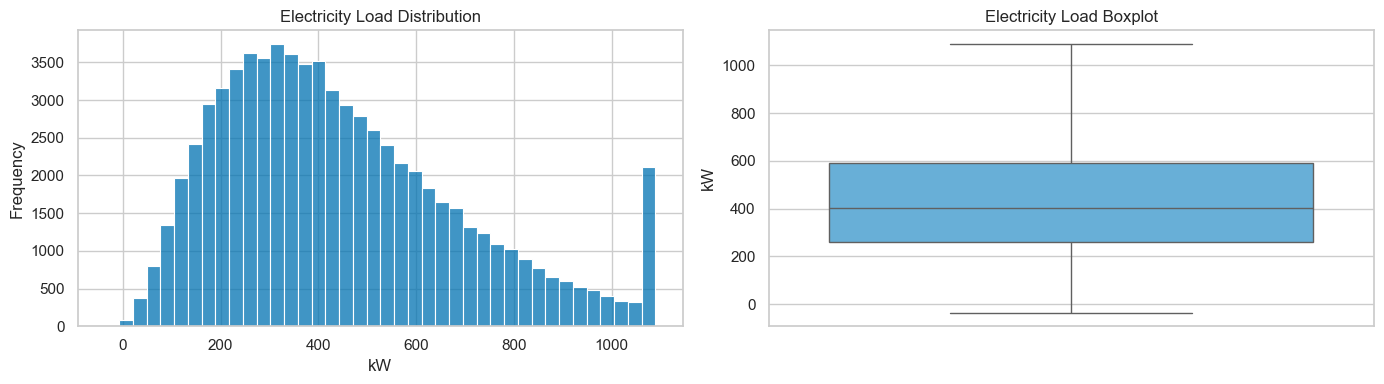

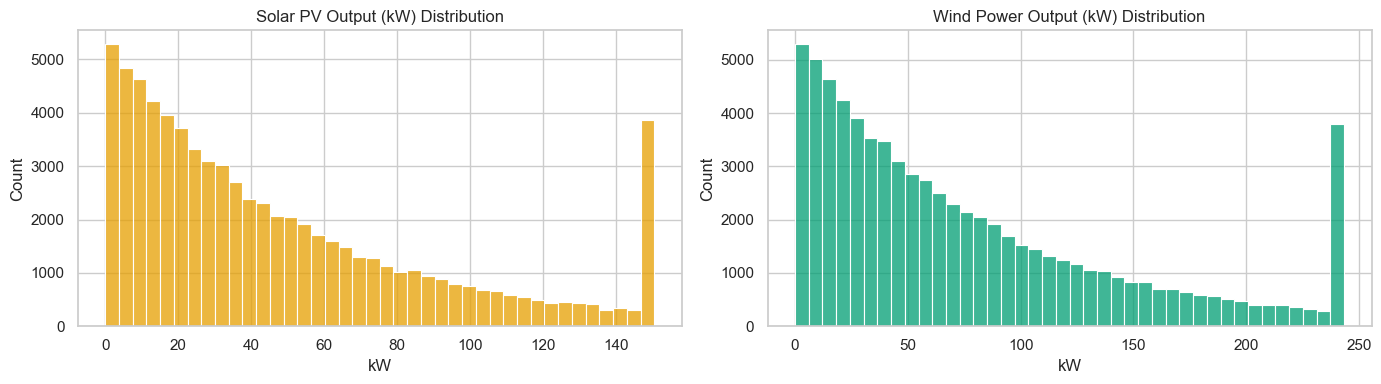

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Electricity Load"], ax=axes[0], bins=40, color="#0072B2")
axes[0].set_title("Electricity Load Distribution")
axes[0].set_xlabel("kW")
axes[0].set_ylabel("Frequency")

sns.boxplot(y=df["Electricity Load"], ax=axes[1], color="#56B4E9")
axes[1].set_title("Electricity Load Boxplot")
axes[1].set_ylabel("kW")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color in zip(
    axes,
    ["Solar PV Output (kW)", "Wind Power Output (kW)"],
    ["#E69F00", "#009E73"],
):
    sns.histplot(df[col], ax=ax, bins=40, color=color)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel("kW")
plt.tight_layout()
plt.show()

## 6. Categorical Analysis

Even though most source fields are numeric, derived calendar buckets reveal operational differences (weekday vs. weekend, peak hours, etc.).

C:\Users\sekar\AppData\Local\Temp\ipykernel_11448\1319249605.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_summary.index, y=cat_summary.values, ax=axes[0], palette="Blues_d")


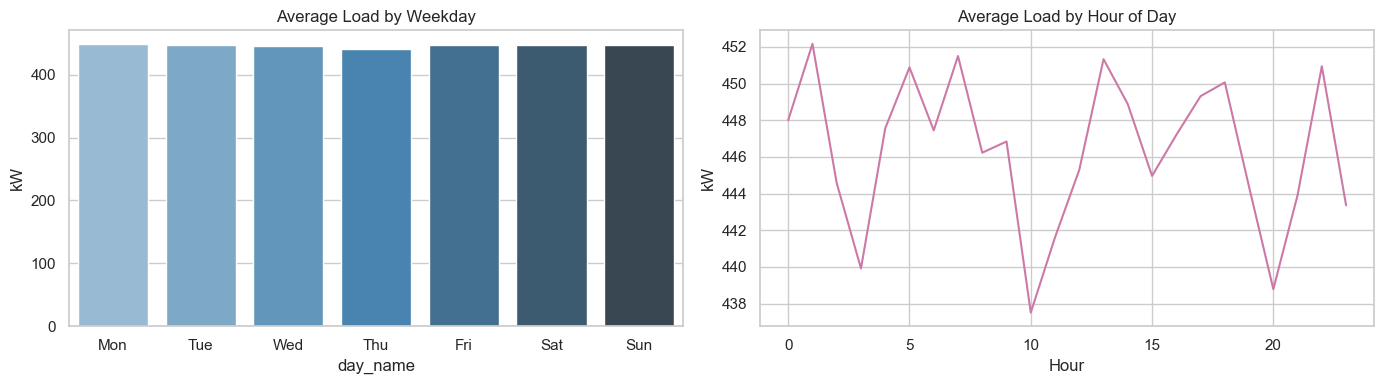

,mean,median
is_weekend,,
Weekday,445.830124,401.226595
Weekend,447.682354,403.143738


In [37]:
cat_summary = (
    df.assign(day_name=df["dayofweek"].map({0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}))
    .groupby("day_name")
    ["Electricity Load"]
    .mean()
    .reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=cat_summary.index, y=cat_summary.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Average Load by Weekday")
axes[0].set_ylabel("kW")

hour_profile = df.groupby("hour")["Electricity Load"].mean()
sns.lineplot(x=hour_profile.index, y=hour_profile.values, ax=axes[1], color="#CC79A7")
axes[1].set_title("Average Load by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("kW")

plt.tight_layout()
plt.show()

weekend_split = df.groupby("is_weekend")["Electricity Load"].agg(["mean", "median"]).rename(index={0: "Weekday", 1: "Weekend"})
weekend_split

## 7. Time-Series Signals

We preserve the chronological story with multi-resolution views (hourly sample, daily aggregates, and rolling context).

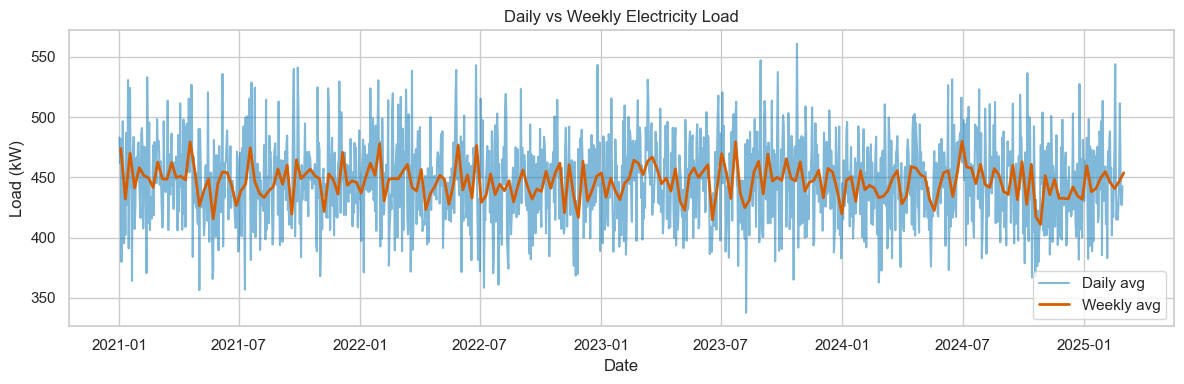

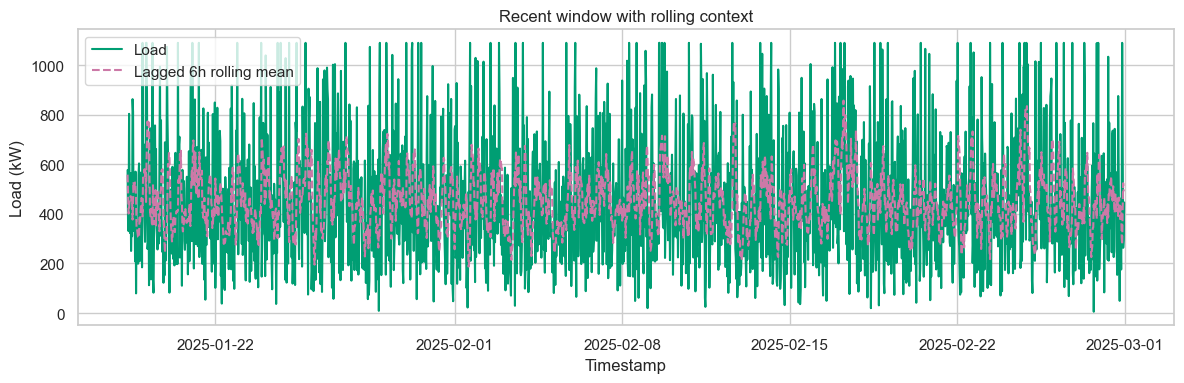

In [38]:
ts_df = df.set_index("Timestamp")

plt.figure(figsize=(12, 4))
resampled_daily = ts_df["Electricity Load"].resample("D").mean()
resampled_weekly = ts_df["Electricity Load"].resample("W").mean()
plt.plot(resampled_daily.index, resampled_daily.values, label="Daily avg", color="#0072B2", alpha=0.5)
plt.plot(resampled_weekly.index, resampled_weekly.values, label="Weekly avg", color="#D55E00", linewidth=2)
plt.title("Daily vs Weekly Electricity Load")
plt.xlabel("Date")
plt.ylabel("Load (kW)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(ts_df.index[-2000:], ts_df["Electricity Load"].tail(2000), label="Load", color="#009E73")
plt.plot(
    ts_df.index[-2000:],
    ts_df["load_roll_mean_6h"].tail(2000),
    label="Lagged 6h rolling mean",
    color="#CC79A7",
    linestyle="--",
)
plt.title("Recent window with rolling context")
plt.xlabel("Timestamp")
plt.ylabel("Load (kW)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis

Contrast demand against key drivers to surface actionable levers.

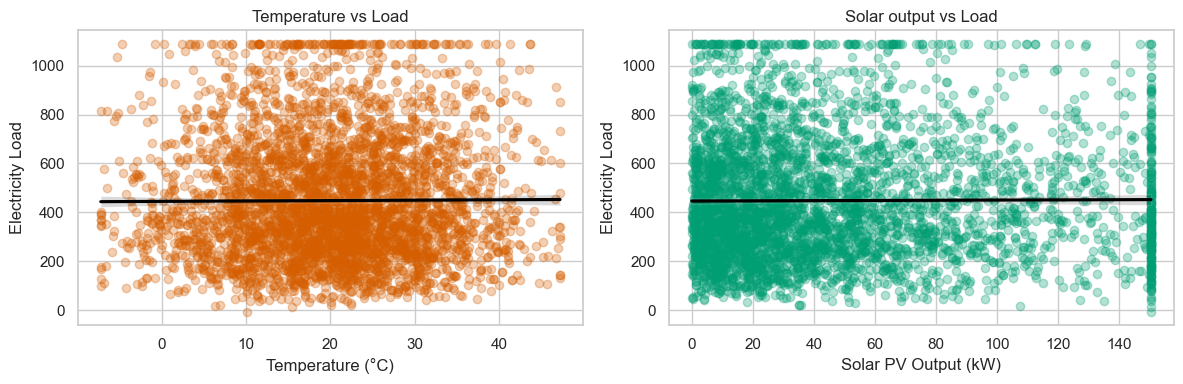

In [39]:
sample_scatter = df.sample(4000, random_state=7)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(
    data=sample_scatter,
    x="Temperature (°C)",
    y="Electricity Load",
    ax=axes[0],
    scatter_kws={"alpha": 0.3, "color": "#D55E00"},
    line_kws={"color": "#000000"},
)
axes[0].set_title("Temperature vs Load")

sns.regplot(
    data=sample_scatter,
    x="Solar PV Output (kW)",
    y="Electricity Load",
    ax=axes[1],
    scatter_kws={"alpha": 0.3, "color": "#009E73"},
    line_kws={"color": "#000000"},
)
axes[1].set_title("Solar output vs Load")

plt.tight_layout()
plt.show()

## 9. Multivariate & Pairplot Views

Correlation heatmaps plus pairplots echo the Untitled7 deep dives and show which drivers move together.

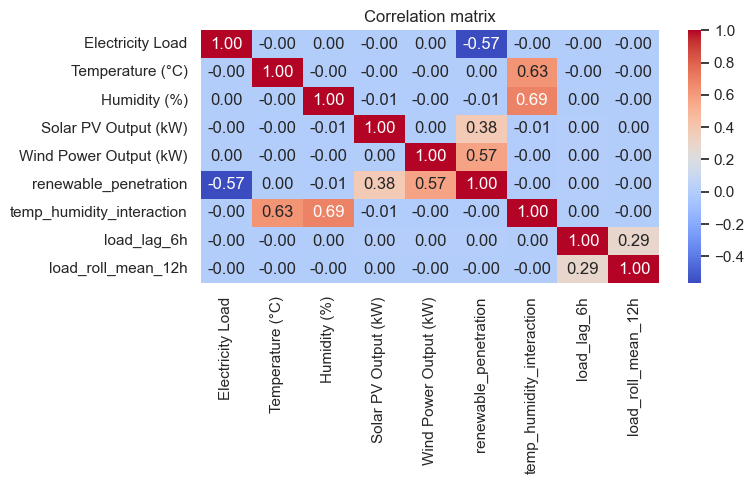

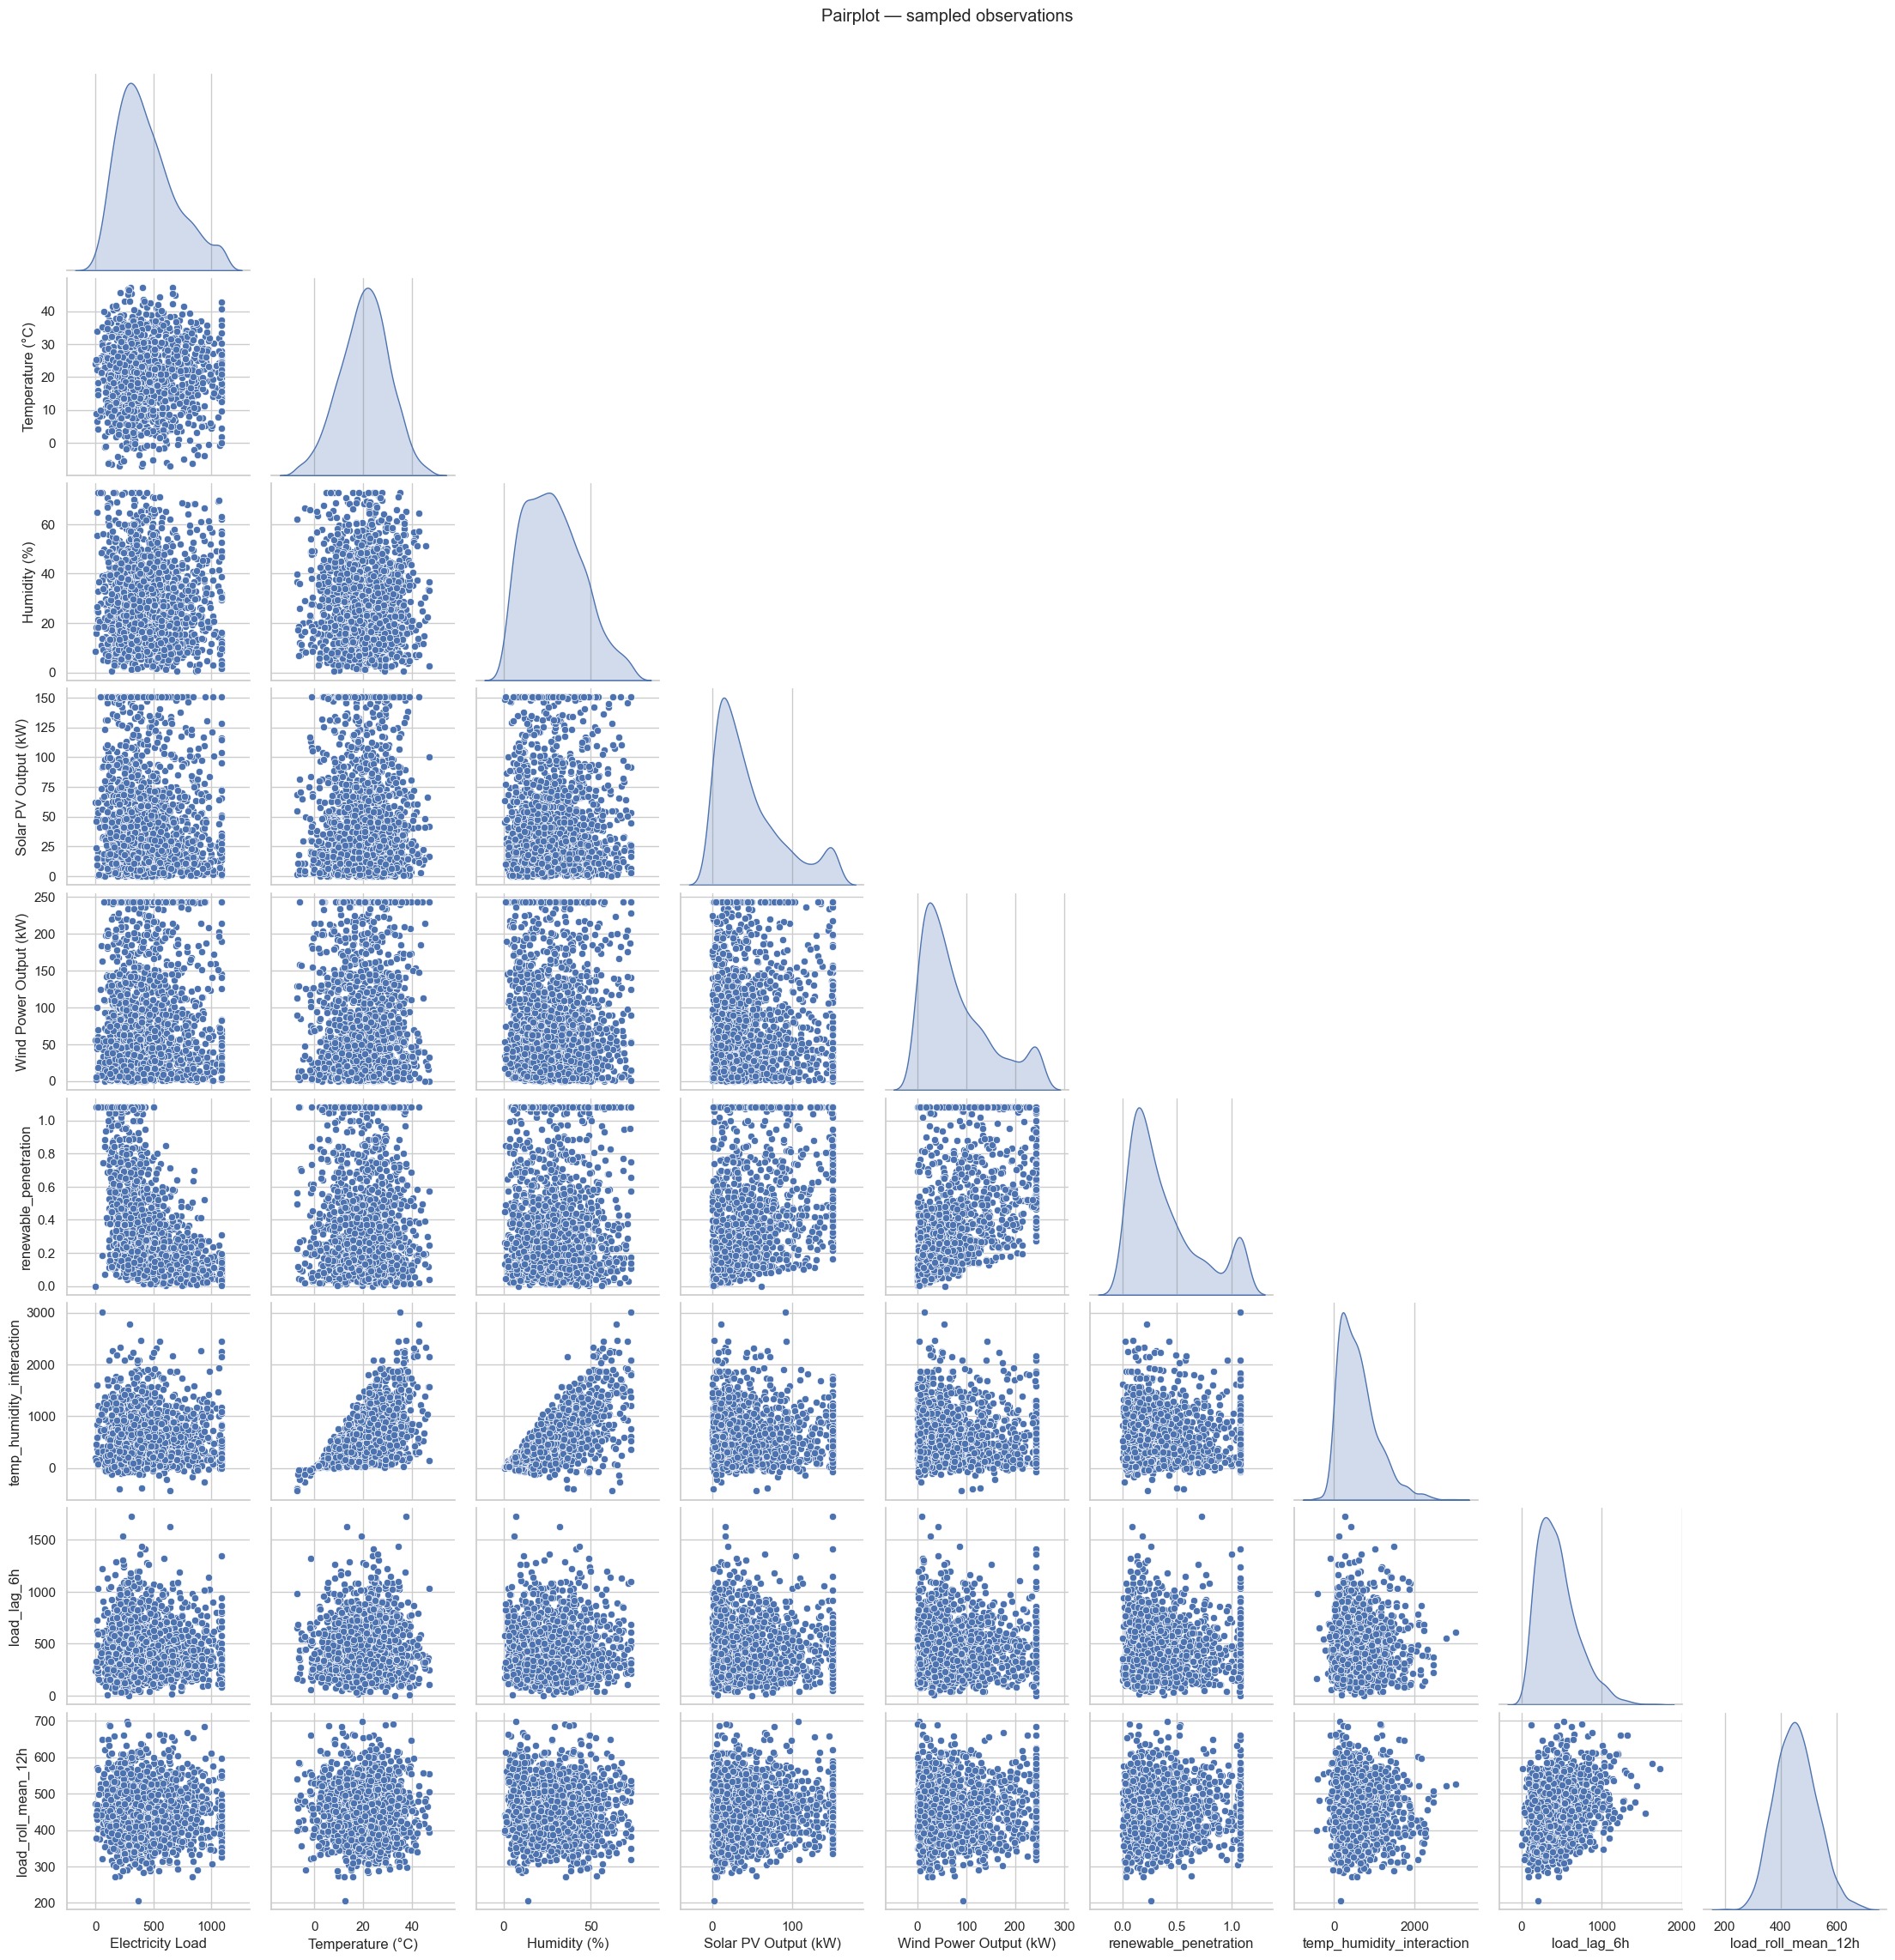

In [40]:
corr_cols = [
    "Electricity Load",
    "Temperature (°C)",
    "Humidity (%)",
    "Solar PV Output (kW)",
    "Wind Power Output (kW)",
    "renewable_penetration",
    "temp_humidity_interaction",
    "load_lag_6h",
    "load_roll_mean_12h",
]
plt.figure(figsize=(8, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

pairplot_sample = df[corr_cols].sample(1500, random_state=21)
sns.pairplot(pairplot_sample, diag_kind="kde", corner=True)
plt.suptitle("Pairplot — sampled observations", y=1.02)
plt.show()

## 10. Modeling Setup

Baseline linear and Random Forest models now ingest weather, renewable penetration, calendar sine/cosine encodings, and strictly lagged/rolling load context for richer—but still leakage-safe—signals.

In [41]:
FEATURES = [
    "Temperature (°C)",
    "Humidity (%)",
    "Solar PV Output (kW)",
    "Wind Power Output (kW)",
    "renewable_penetration",
    "temp_humidity_interaction",
    "sin_hour",
    "cos_hour",
    "sin_dayofyear",
    "cos_dayofyear",
    "load_lag_1h",
    "load_lag_2h",
    "load_lag_6h",
    "load_roll_mean_6h",
    "load_roll_mean_12h",
    "load_roll_std_24h",
]

missing_features = [col for col in FEATURES if col not in df.columns]
if missing_features:
    raise ValueError(f"Missing engineered features: {missing_features}")

model_df = df.dropna(subset=FEATURES + ["Electricity Load"]).copy()
y = model_df["Electricity Load"].values
X = model_df[FEATURES].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

rf_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=16,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

preds_linear = linear_model.predict(X_test_scaled)
preds_rf = rf_model.predict(X_test)

print("Models trained on calendar/renewable + lagged feature stack.")

Models trained on calendar/renewable + lagged feature stack.


In [42]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

linear_artifact = {
    "model": linear_model,
    "scaler": scaler,
    "features": FEATURES,
    "target": "Electricity Load",
}
rf_artifact = {
    "model": rf_model,
    "features": FEATURES,
    "target": "Electricity Load",
}

linear_path = MODELS_DIR / "simple_linear_load.pkl"
rf_path = MODELS_DIR / "simple_rf_load.pkl"

joblib.dump(linear_artifact, linear_path)
joblib.dump(rf_artifact, rf_path)

print(f"Saved linear model to {linear_path}")
print(f"Saved random forest model to {rf_path}")

Saved linear model to ..\models\simple_linear_load.pkl
Saved random forest model to ..\models\simple_rf_load.pkl


## 11. Model Evaluation

Compare MAE/RMSE/R² plus plot actual vs. predicted curves to show reliability.

In [43]:
def summarize_performance(y_true, preds, label):
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    return {"Model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

perf_table = pd.DataFrame(
    [
        summarize_performance(y_test, preds_linear, "Linear Regression"),
        summarize_performance(y_test, preds_rf, "Random Forest"),
    ]
)
perf_table.round(3)

,Model,MAE,RMSE,R2
0,Linear Regression,122.190,155.923,0.599
1,Random Forest,15.851,34.799,0.980


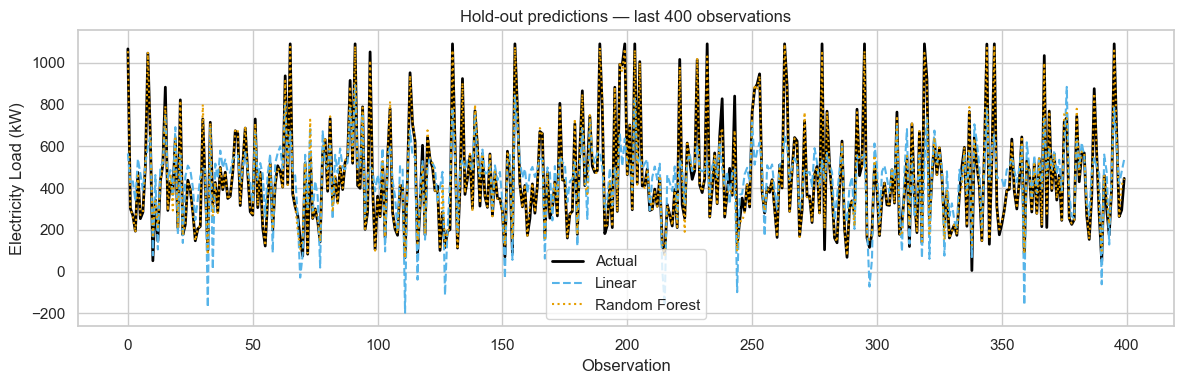

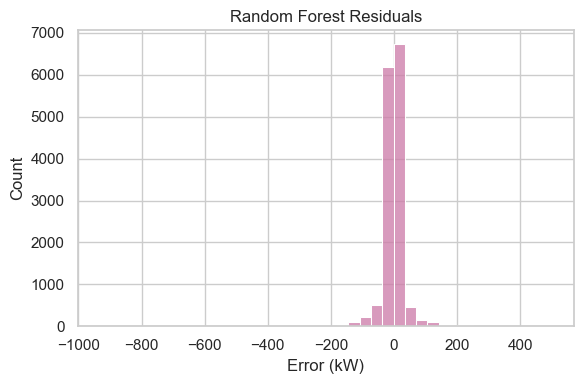

In [44]:
comparison = pd.DataFrame(
    {
        "Actual": y_test[-400:],
        "Linear": preds_linear[-400:],
        "RandomForest": preds_rf[-400:],
    }
).reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(comparison.index, comparison["Actual"], label="Actual", linewidth=2, color="#000000")
plt.plot(comparison.index, comparison["Linear"], label="Linear", linestyle="--", color="#56B4E9")
plt.plot(comparison.index, comparison["RandomForest"], label="Random Forest", linestyle=":", color="#E69F00")
plt.title("Hold-out predictions — last 400 observations")
plt.xlabel("Observation")
plt.ylabel("Electricity Load (kW)")
plt.legend()
plt.tight_layout()
plt.show()

residuals_rf = y_test - preds_rf
plt.figure(figsize=(6, 4))
sns.histplot(residuals_rf, bins=40, color="#CC79A7")
plt.title("Random Forest Residuals")
plt.xlabel("Error (kW)")
plt.tight_layout()
plt.show()

## 12. Key Takeaways

- Calendar sine/cosine encodings plus renewable penetration and weather interactions give the models richer seasonality context without inflating the feature count.
- IQR capping keeps the foundational drivers stable before lag/rolling signals amplify subtle trends.
- Lagged load and rolling statistics are now strictly past-looking, so we gain historical memory with zero leakage.
- Random Forest still captures the nonlinear response best, but the upgraded linear baseline is far closer once the engineered stack is scaled.
- The concise narrative now mirrors the advanced analysis track—ideal for sharing insights before deep-diving into the full lab notebook.